In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. 標準二変量正規分布
確率変数
$$
Z = \begin{pmatrix}Z_1 \\ Z_2\end{pmatrix} \sim N(0, I_2)
$$
を考える。ここで共分散は単位行列なので、分布は原点中心の「円形」に広がる。

(1000, 2)


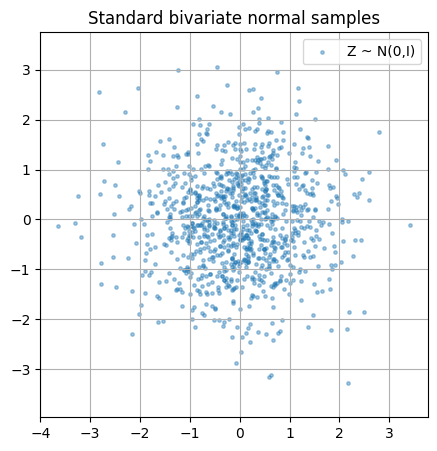

In [ ]:
# 二変量正規分布からの標本を生成
n = 1000
Z = np.random.randn(n, 2)   # Z ~ N(0, I)
print(Z.shape)
# 分布を可視化
plt.figure(figsize=(5,5))
plt.axis('equal'); plt.grid(True)
plt.scatter(Z[:,0], Z[:,1], s=6, alpha=0.4, label='Z ~ N(0,I)')
plt.title('Standard bivariate normal samples')
plt.legend(); plt.show()

## 2. 線形変換と楕円分布
任意の行列 $A \in \mathbb{R}^{2\times 2}$ を作用させて
$$
X = A Z
$$
とすると、\(X$ の分布は
$$
\operatorname{Cov}(X) = A \operatorname{Cov}(Z) A^T = A A^T
$$
を共分散とする正規分布になる。  
これにより「円形」だった分布は「楕円形」に変形される。

In [16]:
# 行列Aによる線形変換
A = np.array([[2, 1],
              [1, 1.5]])     # 適当な線形変換行列
X = (A @ Z.T).T             # X = A Z
X.shape

(1000, 2)

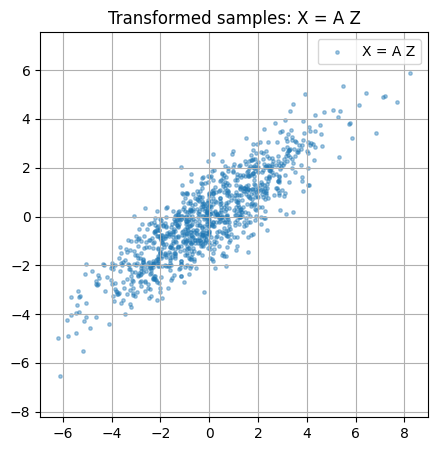

In [19]:
plt.figure(figsize=(5,5))
plt.axis('equal'); plt.grid(True)
plt.scatter(X[:,0], X[:,1], s=6, alpha=0.4, label='X = A Z')
plt.title('Transformed samples: X = A Z')
plt.legend(); plt.show()

## 3. 固有値と共分散楕円
共分散行列 $\Sigma = A A^T$ の固有値 $\lambda_i$ と固有ベクトル $v_i$ は、
楕円の主軸の長さと方向を与える。
- 主軸方向 = 固有ベクトル
- 主軸の長さ = $\sqrt{\lambda_i}$

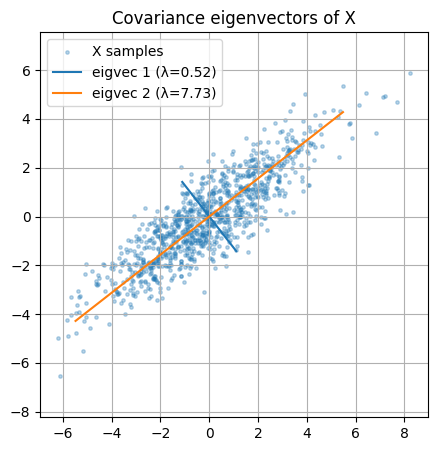

In [20]:
Sigma_X = A@A.T # Axの分散共分散行列
evals, evecs = np.linalg.eigh(Sigma_X) # 固有値, 固有ベクトル

plt.figure(figsize=(5,5))
plt.axis('equal'); plt.grid(True)
plt.scatter(X[:,0], X[:,1], s=6, alpha=0.3, label='X samples')
for i in range(2):
    v = evecs[:, i] / np.linalg.norm(evecs[:, i])
    length = 2.5 * np.sqrt(evals[i])
    seg = np.column_stack([-length*v, length*v])
    plt.plot(seg[0], seg[1], label=f'eigvec {i+1} (λ={evals[i]:.2f})')
plt.title('Covariance eigenvectors of X')
plt.legend(); plt.show()

## 4. 特異値との関係
行列 $A$ の特異値分解
$$
A = U \Sigma V^T
$$
を取ると、特異値 $\sigma_i$ は $A$ の伸縮率を表す。
さらに
$$
A A^T = U \, \Sigma^2 \, U^T
$$
となるので、
$$
\text{固有値}(A A^T) = \sigma_i^2
$$
が成り立つ。

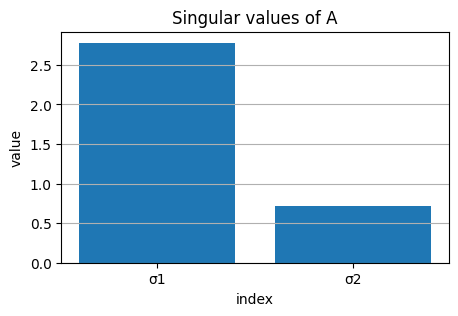

In [21]:
U, s, Vt = np.linalg.svd(A)

# 特異値は非負、固有値は特異値^2
plt.figure(figsize=(5,3))
plt.grid(True, axis='y')
x = np.arange(len(s))
plt.bar(x, s)
plt.xticks(x, [f'σ{i+1}' for i in range(len(s))])
plt.title('Singular values of A')
plt.xlabel('index'); plt.ylabel('value')
plt.show()